# NDVI Signal Exploration

## Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

## Load Dataset

In [37]:
df = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/04_Phase_2_Time_Series/Layer B_Signal Behavior/dataset/ndvi_timeseries.csv")

print("First 5 rows")
display(df.head())

First 5 rows


,system:index,NDVI,date,.geo
0,20230109T044139_20230109T044620_T45RYH,0.533609,2023-01-09,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,20230119T044119_20230119T044439_T45RYH,0.379122,2023-01-19,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,20230124T044101_20230124T044838_T45RYH,0.570066,2023-01-24,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,20230203T044011_20230203T044612_T45RYH,0.536162,2023-02-03,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,20230213T043911_20230213T044313_T45RYH,0.481330,2023-02-13,"{""type"":""MultiPoint"",""coordinates"":[]}"


## Convert Date Column

In [38]:
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.time_processing import prepare_time_index

df = prepare_time_index(df)

## Droping the Extra Column

In [39]:
df = df.drop(
    columns=['system:index', '.geo'],
    errors='ignore'
    )

## Check & Remove missing value

In [40]:
# Check
df.isnull().sum()

# Validate
df[df.isnull().any(axis=1)]

,NDVI
date,
2024-12-24,NaN


In [41]:
# Remove
df.dropna(inplace=True)

## Check Duplicate Dates

In [42]:
# Check
duplicates = df.index.duplicated().sum()

print(f"Duplicate dates : {duplicates}")

# Validate
if duplicates > 0:
    print(df[df.index.duplicated(keep=False)])

Duplicate dates : 3
                NDVI
date                
2023-11-20  0.566345
2023-11-20  0.528334
2023-12-30  0.378959
2023-12-30  0.386829
2024-12-14  0.265595
2024-12-14  0.264753


In [43]:
# Remove
df = df[~df.index.duplicated(keep="first")]

# verify
print("Duplicate dates:", df.index.duplicated().sum())

Duplicate dates: 0


## Descriptive Statistics

In [44]:
df["NDVI"].describe()

,NDVI
count,69.000000
mean,0.517823
std,0.167828
min,0.196364
25%,0.388447
50%,0.510964
75%,0.674033
max,0.830655


## Raw NDVI Time Series

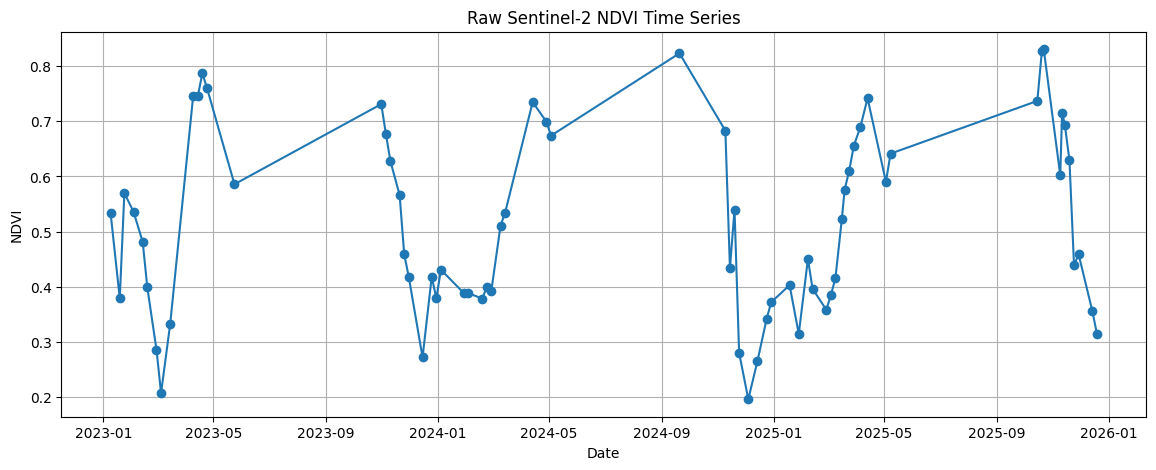

In [45]:
plt.figure(figsize=(14,5))

plt.plot(
    df.index,
    df["NDVI"],
    marker="o",
    linewidth=1.5
)

plt.title("Raw Sentinel-2 NDVI Time Series")
plt.xlabel("Date")
plt.ylabel("NDVI")

plt.grid(True)

plt.show()

## Observation Timeline

**On which dates did the satellite successfully observe the field?**

    Every vertical line (|) represents one successful Sentinel-2 observation.

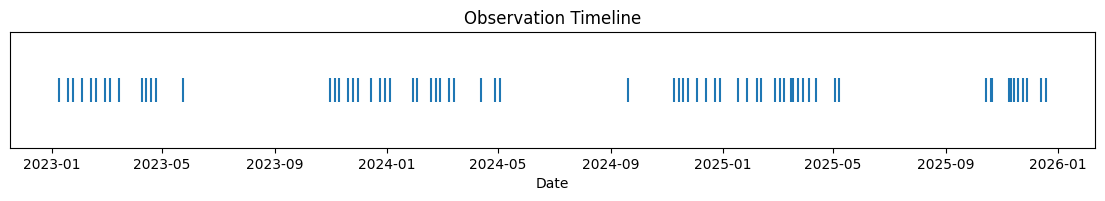

In [46]:
plt.figure(figsize=(14,1.5))

plt.scatter(
    df.index,
    np.zeros(len(df)),
    marker="|",
    s=300
)

plt.yticks([])

plt.title("Observation Timeline")

plt.xlabel("Date")

plt.show()

## Calculate Revisit Interval

In [47]:
df["Gap_Days"] = df.index.to_series().diff().dt.days #This also convert date gap to the integer value.

display(df.head())

,NDVI,Gap_Days
date,,
2023-01-09,0.533609,NaN
2023-01-19,0.379122,10.0
2023-01-24,0.570066,5.0
2023-02-03,0.536162,10.0
2023-02-13,0.481330,10.0


## Revisit Statistics

In [50]:
gap = df["Gap_Days"].dropna()

print("="*40)
print("Revisit Interval Statistics")
print("="*40)
gap.describe()

Revisit Interval Statistics


,Gap_Days
count,68.000000
mean,15.808824
std,30.880732
min,2.000000
25%,5.000000
50%,5.000000
75%,10.000000
max,160.000000


## Long Gap Detection

In [51]:
threshold = 20

long_gaps = df[df["Gap_Days"] > threshold]

print(f"Number of gaps > {threshold} days")

display(long_gaps)

Number of gaps > 20 days


,NDVI,Gap_Days
date,,
2023-04-09,0.746060,25.0
2023-05-24,0.585936,30.0
2023-10-31,0.731171,160.0
2024-01-29,0.388728,25.0
2024-04-13,0.734804,30.0
2024-09-20,0.823319,140.0
2024-11-09,0.683078,50.0
2025-10-15,0.736960,160.0


## NDVI histogram and boxplot

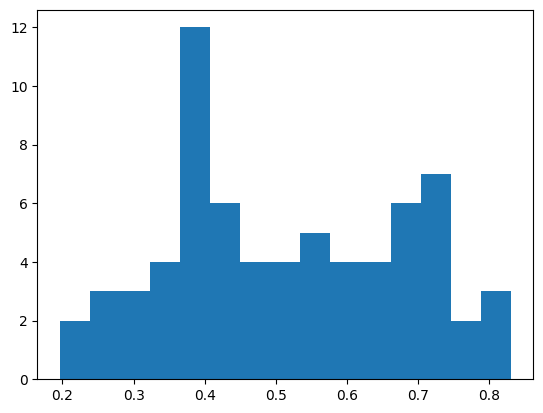

In [61]:
plt.hist(df["NDVI"], bins=15)
plt.show()

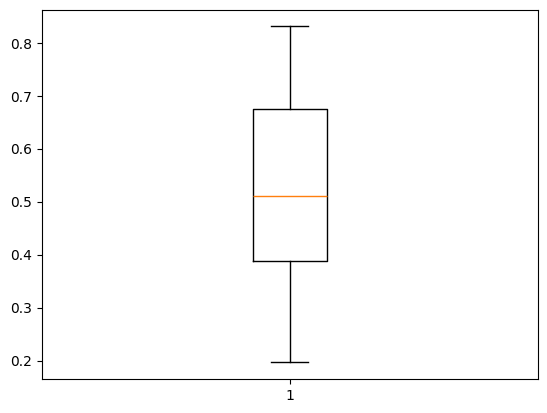

In [60]:
plt.boxplot(df["NDVI"])
plt.show()